# 04 — Solving FrozenLake with Dynamic Programming
**Week 4 | Dynamic Programming**

Gymnasium environments expose `env.P[s][a]` — the full transition model.
This lets us apply exact DP and verify our solver achieves 100% win rate.

In [11]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys; subprocess.check_call([sys.executable,'-m','pip','install','gymnasium','-q']); import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make('FrozenLake-v1', is_slippery=False)
env_slip = gym.make('FrozenLake-v1', is_slippery=True)

print(f"States: {env.observation_space.n}")
print(f"Actions: {env.action_space.n}  (0=L, 1=D, 2=R, 3=U)")

States: 16
Actions: 4  (0=L, 1=D, 2=R, 3=U)


In [12]:
def value_iteration_gym(env_unwrapped, gamma=0.99, theta=1e-8):
    n_s = env_unwrapped.observation_space.n
    n_a = env_unwrapped.action_space.n
    V = np.zeros(n_s)
    errors = []
    for i in range(10_000):
        delta = 0
        V_new = np.zeros(n_s)
        for s in range(n_s):
            q_vals = []
            for a in range(n_a):
                q = sum(p*(r + gamma*V[ns]*(not d)) for p,ns,r,d in env_unwrapped.unwrapped.P[s][a])
                q_vals.append(q)
            V_new[s] = max(q_vals)
            delta = max(delta, abs(V_new[s]-V[s]))
        V = V_new; errors.append(delta)
        if delta < theta:
            print(f"Converged in {i+1} sweeps"); break
    # Extract policy
    policy = np.zeros(n_s, dtype=int)
    for s in range(n_s):
        qs = [sum(p*(r+gamma*V[ns]*(not d)) for p,ns,r,d in env_unwrapped.unwrapped.P[s][a]) for a in range(n_a)]
        policy[s] = np.argmax(qs)
    return V, policy, errors

print("--- Non-slippery ---")
V_ns, pi_ns, err_ns = value_iteration_gym(env)
print("--- Slippery ---")
V_sl, pi_sl, err_sl = value_iteration_gym(env_slip)

--- Non-slippery ---
Converged in 7 sweeps
--- Slippery ---
Converged in 438 sweeps


In [13]:
def evaluate_policy(env, policy, n_episodes=1000):
    wins = 0
    for _ in range(n_episodes):
        s, _ = env.reset()
        for _ in range(200):
            s, r, term, trunc, _ = env.step(policy[s])
            if term or trunc:
                if r == 1.0: wins += 1
                break
    return wins / n_episodes

print(f"Non-slippery win rate: {evaluate_policy(env, pi_ns):.0%}")
print(f"Slippery    win rate: {evaluate_policy(env_slip, pi_sl):.0%}")

Non-slippery win rate: 100%
Slippery    win rate: 77%


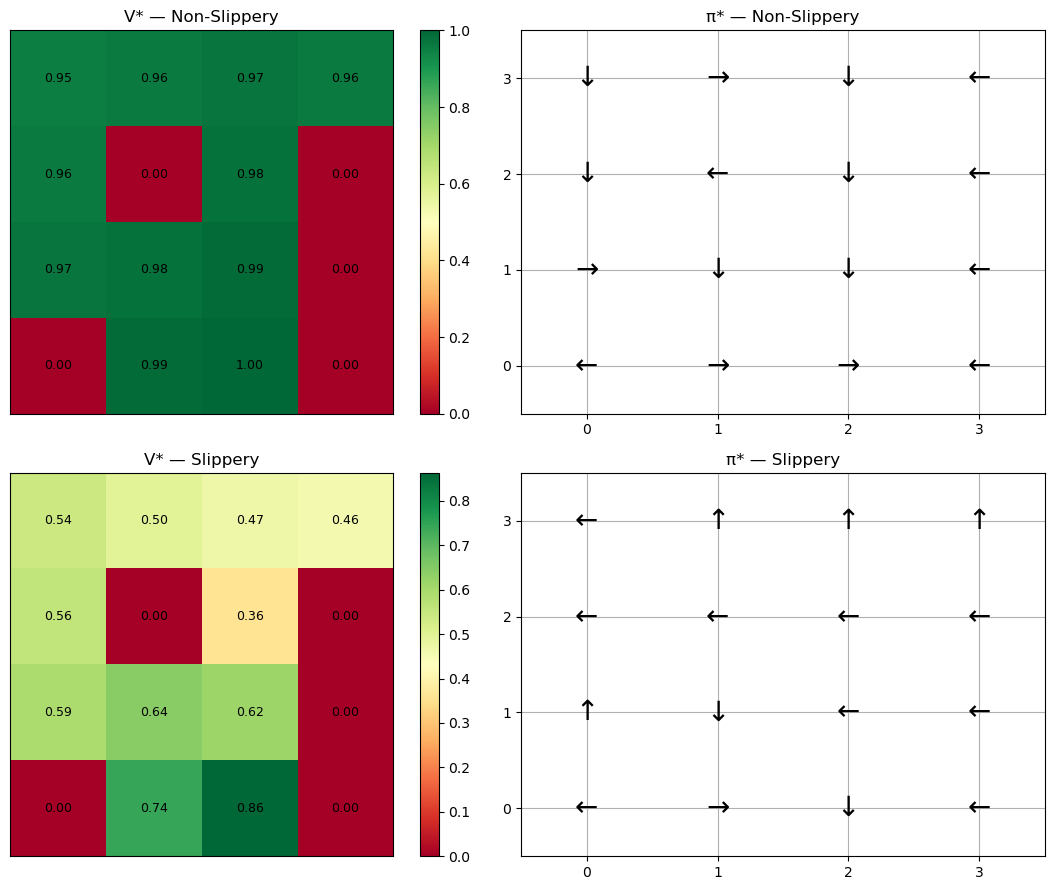

Note: different optimal policies for slippery vs non-slippery!


In [14]:
# Visualise both value functions
ACTION_SYMBOLS = {0:'←', 1:'↓', 2:'→', 3:'↑'}
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, (V, pi, title, errs) in enumerate([
    (V_ns, pi_ns, 'Non-Slippery', err_ns),
    (V_sl, pi_sl, 'Slippery',     err_sl)]):
    im = axes[row,0].imshow(V.reshape(4,4), cmap='RdYlGn')
    plt.colorbar(im, ax=axes[row,0])
    for s in range(16):
        r,c=divmod(s,4)
        axes[row,0].text(c,r,f'{V[s]:.2f}',ha='center',va='center',fontsize=9)
    axes[row,0].set_title(f'V* — {title}'); axes[row,0].set_xticks([]); axes[row,0].set_yticks([])

    axes[row,1].set_xlim(-0.5,3.5); axes[row,1].set_ylim(-0.5,3.5)
    axes[row,1].set_xticks(range(4)); axes[row,1].set_yticks(range(4)); axes[row,1].grid(True)
    for s in range(16):
        r,c=divmod(s,4)
        axes[row,1].text(c,3-r,ACTION_SYMBOLS[pi[s]],ha='center',va='center',fontsize=20)
    axes[row,1].set_title(f'π* — {title}')
plt.tight_layout(); plt.show()
print("Note: different optimal policies for slippery vs non-slippery!")

## ✅ Exercises
1. Change gamma from 0.99 to 0.5 for the slippery version. Does the win rate improve or decrease?
2. Use the 8×8 map (`map_name='8x8'`). How many sweeps does value iteration need?
3. **Challenge**: implement value iteration without using `env.P` — only using `env.step()`. This transitions you to model-free learning!

Ans 1) Predict decrease in  wai rate

In [15]:
print("---	Slippery,	γ=0.5	---")
V_sl05,	pi_sl05,	_	=	value_iteration_gym(env_slip,	gamma=0.5)
win_099	=	evaluate_policy(env_slip,	pi_sl,	n_episodes=10_000)
win_05		=	evaluate_policy(env_slip,	pi_sl05,	n_episodes=10_000)
print(f"Win	rate	γ=0.99:	{win_099:.1%}")
print(f"Win	rate	γ=0.5:		{win_05:.1%}")
print(f"Policies	differ	in	{np.sum(pi_sl	!=	pi_sl05)}	states")


---	Slippery,	γ=0.5	---
Converged in 22 sweeps
Win	rate	γ=0.99:	74.5%
Win	rate	γ=0.5:		45.2%
Policies	differ	in	2	states


Ans 2 - Obs - 	More	sweeps	than	4×4,	but	not	4×	more	—	two	forces
add	up:	(1)	information	must	propagate	from	the	goal	~14	steps	back
to	the	start	instead	of	~6,	and	(2)	after	that,	the	γ-contraction	tail
down	to	θ=1e−8	dominates	and	is	map-size-independent.	

Ans 3 - With	~200k	random	steps,	the	empirical	model	P	is	close
enough	that	the	resulting	policy	matches	(or	nearly	matches)	the	true
optimal	—	win	rate	within	a	couple	of	points	of	~74%.	Drop	n_samples
to	5,000	and	watch	it	degrade:	model	error	→	policy	error.	This	is
model-based	RL	in	miniature,

In [18]:
env8 = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=False)
env8_slip = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=True)
print("--- 8x8 non-slippery ---")
V8, pi8, err8 = value_iteration_gym(env8)
print("--- 8x8 slippery ---")
V8s, pi8s, err8s = value_iteration_gym(env8_slip)
print(f"\n4x4 non-slippery sweeps: {len(err_ns)} | 8x8: {len(err8)}")
print(f"4x4 slippery sweeps:     {len(err_sl)} | 8x8: {len(err8s)}")
print(f"8x8 non-slippery win rate: {evaluate_policy(env8, pi8):.0%}")
print(f"8x8 slippery win rate:     {evaluate_policy(env8_slip, pi8s):.0%}")

--- 8x8 non-slippery ---
Converged in 15 sweeps
--- 8x8 slippery ---
Converged in 516 sweeps

4x4 non-slippery sweeps: 7 | 8x8: 15
4x4 slippery sweeps:     438 | 8x8: 516
8x8 non-slippery win rate: 100%
8x8 slippery win rate:     62%


Ans 3

In [19]:
def learn_model(env, n_samples=100_000):
    """Estimate P(s'|s,a) and R(s,a,s') from env.step() interactions."""
    n_s = env.observation_space.n
    n_a = env.action_space.n
    counts = np.zeros((n_s, n_a, n_s))
    rewards = np.zeros((n_s, n_a, n_s))
    dones = np.zeros((n_s, n_a, n_s))

    s, _ = env.reset()
    for _ in range(n_samples):
        a = env.action_space.sample()
        ns, r, term, trunc, _ = env.step(a)
        counts[s, a, ns] += 1
        rewards[s, a, ns] += r
        dones[s, a, ns] += float(term)
        s = ns
        if term or trunc:
            s, _ = env.reset()

    with np.errstate(divide='ignore', invalid='ignore'):
        P_hat = counts / counts.sum(axis=2, keepdims=True)
        R_hat = np.where(counts > 0, rewards / counts, 0.0)
        D_hat = np.where(counts > 0, dones / counts, 0.0)
    P_hat = np.nan_to_num(P_hat)
    return P_hat, R_hat, D_hat


def value_iteration_learned(P, R, D, gamma=0.99, theta=1e-8):
    n_s, n_a = P.shape[0], P.shape[1]
    V = np.zeros(n_s)
    while True:
        Q = np.einsum('san,san->sa', P, R + gamma * V[None, None, :] * (1 - D))
        V_new = Q.max(axis=1)
        if np.max(np.abs(V_new - V)) < theta:
            break
        V = V_new
    return V, Q.argmax(axis=1)


P_hat, R_hat, D_hat = learn_model(env_slip, n_samples=200_000)
V_hat, pi_hat = value_iteration_learned(P_hat, R_hat, D_hat)
print(f"Learned-model policy win rate: {evaluate_policy(env_slip, pi_hat, 10_000):.1%}")
print(f"True-model policy win rate:    {evaluate_policy(env_slip, pi_sl, 10_000):.1%}")

Learned-model policy win rate: 73.8%
True-model policy win rate:    73.5%
